In [183]:
%matplotlib inline
!pip install monai
!pip install ants
!pip install pyvista


In [184]:
import os
import torch
import torch.nn.functional as F
import nibabel as nib
import numpy as np
import SimpleITK as sitk
import xml.etree.ElementTree as ET
from scipy import ndimage
from skimage.measure import marching_cubes
from scipy.ndimage import binary_dilation
from monai.networks.nets import UNet

# Load model
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=0,
)
checkpoint = torch.load('/kaggle/input/datasets/adham97/brats-unet-model/StandardUNet_best (1).pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [185]:
# Paths
base        = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
patient_id  = "BraTS20_Training_001"
patient_dir = os.path.join(base, patient_id)

def load_and_preprocess(path):
    data = nib.load(path).get_fdata()
    data = (data - np.mean(data)) / (np.std(data) + 1e-8)
    return data

t1    = load_and_preprocess(f"{patient_dir}/{patient_id}_t1.nii")
t1ce  = load_and_preprocess(f"{patient_dir}/{patient_id}_t1ce.nii")
t2    = load_and_preprocess(f"{patient_dir}/{patient_id}_t2.nii")
flair = load_and_preprocess(f"{patient_dir}/{patient_id}_flair.nii")

ref_img     = nib.load(f"{patient_dir}/{patient_id}_t1.nii")
voxel_dims  = ref_img.header.get_zooms()
voxel_vol   = float(voxel_dims[0]) * float(voxel_dims[1]) * float(voxel_dims[2])

print("MRI loaded successfully")
print(f"Shape: {t1.shape}")
print(f"Voxel size: {voxel_dims}")

MRI loaded successfully
Shape: (240, 240, 155)
Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [186]:
def pad_to_divisible(tensor, divisor=16):
    _, _, D, H, W = tensor.shape
    pad_D = (divisor - D % divisor) % divisor
    pad_H = (divisor - H % divisor) % divisor
    pad_W = (divisor - W % divisor) % divisor
    return F.pad(tensor, (0, pad_W, 0, pad_H, 0, pad_D))

# Build tensor
volume       = np.stack([t1, t1ce, t2, flair], axis=0)
input_tensor = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)
input_tensor = pad_to_divisible(input_tensor, divisor=16)
print("Input shape:", input_tensor.shape)

# Run inference
with torch.no_grad():
    output = model(input_tensor)

pred = torch.argmax(output, dim=1)
mask = pred.squeeze().cpu().numpy()

# Crop back to original size
D, H, W = t1.shape
mask = mask[:D, :H, :W]

print("Mask shape:", mask.shape)
print("Unique classes:", np.unique(mask))

Input shape: torch.Size([1, 4, 240, 240, 160])
Mask shape: (240, 240, 155)
Unique classes: [0 1 2 3]


In [187]:
# Extract each region
ncr_mask    = (mask == 1).astype(np.uint8)
edema_mask  = (mask == 2).astype(np.uint8)
et_mask     = (mask == 3).astype(np.uint8)
tumor_core  = ((mask == 1) | (mask == 3)).astype(np.uint8)
whole_tumor = (mask > 0).astype(np.uint8)

# Print volumes
print("── Tumor Volumes ────────────────────────")
for name, m in [("Necrotic Core",   ncr_mask),
                ("Edema",           edema_mask),
                ("Enhancing Tumor", et_mask),
                ("Tumor Core",      tumor_core),
                ("Whole Tumor",     whole_tumor)]:
    vol = np.sum(m) * voxel_vol / 1000
    print(f"  {name:20s}: {vol:.2f} cm³")

# Surgical target centroid (enhancing tumor)
centroid_vox = ndimage.center_of_mass(et_mask)
affine       = ref_img.affine
centroid_mm  = (affine @ np.array([*centroid_vox, 1.0]))[:3]
print(f"\nSurgical target centroid (mm): {centroid_mm}")

# Save masks
np.save('/kaggle/working/tumor_mask.npy',      mask)
np.save('/kaggle/working/et_mask.npy',         et_mask)
np.save('/kaggle/working/ncr_mask.npy',        ncr_mask)
np.save('/kaggle/working/edema_mask.npy',      edema_mask)
np.save('/kaggle/working/whole_tumor.npy',     whole_tumor)
np.save('/kaggle/working/surgical_target.npy', centroid_mm)
print("\nAll masks saved")

── Tumor Volumes ────────────────────────
  Necrotic Core       : 56.33 cm³
  Edema               : 307.81 cm³
  Enhancing Tumor     : 81.98 cm³
  Tumor Core          : 138.31 cm³
  Whole Tumor         : 446.12 cm³

Surgical target centroid (mm): [-94.89261188  87.73810424  50.41169511]

All masks saved


In [188]:
def make_mesh(mask_array, filename, affine):
    print(f"Processing {filename}...")
    
    mask_dilated        = binary_dilation(mask_array, iterations=1)
    verts, faces, _, _  = marching_cubes(mask_dilated, level=0.5)
    
    # Apply affine to transform voxel coords → mm space
    verts_h    = np.hstack([verts, np.ones((len(verts), 1))])
    verts_mm   = (affine @ verts_h.T).T[:, :3]
    
    import pyvista as pv
    faces_pv = np.hstack([np.full((len(faces), 1), 3), faces])
    mesh     = pv.PolyData(verts_mm, faces_pv)
    mesh     = mesh.smooth(n_iter=100)
    mesh.save(f'/kaggle/working/{filename}')
    print(f"  Saved — {len(verts)} vertices, {len(faces)} faces")

# Generate all meshes
make_mesh(whole_tumor,  'whole_tumor.vtk',       affine)
make_mesh(edema_mask,   'edema.vtk',              affine)
make_mesh(et_mask,      'enhancing_tumor.vtk',    affine)
make_mesh(ncr_mask,     'necrotic_core.vtk',      affine)

print("\nAll meshes saved to /kaggle/working/")

Processing whole_tumor.vtk...
  Saved — 86339 vertices, 172878 faces
Processing edema.vtk...
  Saved — 115743 vertices, 232166 faces
Processing enhancing_tumor.vtk...
  Saved — 90186 vertices, 180932 faces
Processing necrotic_core.vtk...
  Saved — 60562 vertices, 121704 faces

All meshes saved to /kaggle/working/


In [189]:
# ============================================================
# STEP 5 — FIX: Re-download Harvard-Oxford Atlas
# Cell: Atlas Download & Verification
# ============================================================
import os, gzip, subprocess, urllib.request, shutil
import nibabel as nib
import numpy as np

ATLAS_DIR = '/kaggle/working/atlas/data/atlases/HarvardOxford'
XML_DIR   = '/kaggle/working/atlas/data/atlases'
os.makedirs(ATLAS_DIR, exist_ok=True)

ATLAS_FILE = f'{ATLAS_DIR}/HarvardOxford-cort-maxprob-thr25-1mm.nii.gz'
XML_FILE   = f'{XML_DIR}/HarvardOxford-Cortical.xml'

# ── Helper: verify a .nii.gz is actually readable ─────────────
def verify_nii_gz(path):
    try:
        with gzip.open(path, 'rb') as f:
            f.read(128)           # just read header bytes
        img = nib.load(path)
        _ = img.get_fdata()
        return True
    except Exception as e:
        print(f"   ✗ Corrupt/missing: {path}\n     Reason: {e}")
        return False

# ── Check current state ───────────────────────────────────────
print("=" * 60)
print("Atlas File Diagnostics")
print("=" * 60)

for path in [ATLAS_FILE, XML_FILE]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    print(f"\n{'✅' if exists else '✗'} {os.path.basename(path)}")
    print(f"   Exists : {exists}")
    print(f"   Size   : {size:,} bytes")
    if exists and path.endswith('.nii.gz'):
        verify_nii_gz(path)

# ── Method 1: FSL built-in atlases (fastest — check if FSL exists) ──
print("\n" + "=" * 60)
print("Method 1: Check FSL installation")
print("=" * 60)

fsl_atlas_path = '/usr/share/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-1mm.nii.gz'
fsl_xml_path   = '/usr/share/fsl/data/atlases/HarvardOxford-Cortical.xml'

fsl_found = os.path.exists(fsl_atlas_path)
print(f"FSL atlas found: {fsl_found}")

if fsl_found and verify_nii_gz(fsl_atlas_path):
    print("✅ FSL atlas is valid — copying to working dir")
    shutil.copy2(fsl_atlas_path, ATLAS_FILE)
    if os.path.exists(fsl_xml_path):
        shutil.copy2(fsl_xml_path, XML_FILE)
    print("✅ Copied from FSL installation")
else:
    # ── Method 2: pip install neuroimaging atlas package ────────
    print("\n" + "=" * 60)
    print("Method 2: nilearn Harvard-Oxford atlas")
    print("=" * 60)
    try:
        from nilearn import datasets
        print("Downloading via nilearn (auto-cached)...")

        ho = datasets.fetch_atlas_harvard_oxford(
            'cort-maxprob-thr25-1mm',
            data_dir='/kaggle/working/nilearn_data',
            symmetric_split=False
        )

        src_atlas = ho['maps']
        print(f"   nilearn atlas path: {src_atlas}")

        # Verify it loaded
        img   = nib.load(src_atlas)
        data  = img.get_fdata()
        print(f"   Atlas shape : {data.shape}")
        print(f"   Unique labels: {np.unique(data).shape[0]}")

        # Copy to expected location
        shutil.copy2(src_atlas, ATLAS_FILE)
        print(f"✅ Atlas copied → {ATLAS_FILE}")

        # Build XML label file from nilearn label list
        import xml.etree.ElementTree as ET
        labels_list = ho['labels']
        print(f"   Labels found: {len(labels_list)}")

        root_xml = ET.Element("atlas")
        ET.SubElement(root_xml, "header")
        data_el  = ET.SubElement(root_xml, "data")
        for i, name in enumerate(labels_list):
            lbl = ET.SubElement(data_el, "label")
            lbl.set("index", str(i))
            lbl.text = str(name)

        tree_xml = ET.ElementTree(root_xml)
        ET.indent(tree_xml, space="  ")
        tree_xml.write(XML_FILE, encoding="unicode", xml_declaration=False)
        print(f"✅ XML labels written → {XML_FILE}")

    except Exception as e:
        print(f"✗ nilearn failed: {e}")

        # ── Method 3: Direct URL download (fallback) ────────────
        print("\n" + "=" * 60)
        print("Method 3: Direct download from GitHub mirror")
        print("=" * 60)

        URLS = {
            ATLAS_FILE: (
                "https://github.com/neurolabusc/AtlasesForSlicer/raw/master/"
                "HarvardOxford-cort-maxprob-thr25-1mm.nii.gz"
            ),
            XML_FILE: (
                "https://raw.githubusercontent.com/neurolabusc/AtlasesForSlicer/"
                "master/HarvardOxford-Cortical.xml"
            ),
        }

        for dest, url in URLS.items():
            print(f"   Downloading {os.path.basename(dest)} ...")
            try:
                urllib.request.urlretrieve(url, dest)
                size = os.path.getsize(dest)
                print(f"   ✅ {os.path.basename(dest)} — {size:,} bytes")
            except Exception as dl_err:
                print(f"   ✗ Failed: {dl_err}")

# ── Final verification ────────────────────────────────────────
print("\n" + "=" * 60)
print("Final Verification")
print("=" * 60)

atlas_ok = verify_nii_gz(ATLAS_FILE)
xml_ok   = os.path.exists(XML_FILE) and os.path.getsize(XML_FILE) > 100

if atlas_ok:
    img  = nib.load(ATLAS_FILE)
    data = img.get_fdata().astype('int32')
    print(f"\n✅ Atlas loaded successfully")
    print(f"   Shape         : {data.shape}")
    print(f"   Affine        :\n{img.affine}")
    print(f"   Unique labels : {np.unique(data)}")
else:
    print("\n✗ Atlas still not valid — see error above")

if xml_ok:
    print(f"✅ XML file OK ({os.path.getsize(XML_FILE):,} bytes)")
else:
    print("✗ XML file missing or empty")

if atlas_ok and xml_ok:
    print("\n✅ All atlas files ready — proceed with Step 5 registration cell")
else:
    print("\n✗ Fix failed — paste the error above and we'll try another approach")

Atlas File Diagnostics

✅ HarvardOxford-cort-maxprob-thr25-1mm.nii.gz
   Exists : True
   Size   : 146,506 bytes

✅ HarvardOxford-Cortical.xml
   Exists : True
   Size   : 4,335 bytes

Method 1: Check FSL installation
FSL atlas found: False

Method 2: nilearn Harvard-Oxford atlas


[fetch_atlas_harvard_oxford] Dataset found in /kaggle/working/nilearn_data/fsl

   nilearn atlas path: 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (182, 218, 182)
affine:
[[   1.    0.    0.  -91.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 182 218 182   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FSL3.

In [190]:
# ============================================================
# FIX: Replace corrupt atlas with valid nilearn cached copy
# ============================================================
import shutil, os
import nibabel as nib
import numpy as np
import xml.etree.ElementTree as ET

# ── The problem ───────────────────────────────────────────────
# /kaggle/working/atlas/.../HarvardOxford-cort-maxprob-thr25-1mm.nii.gz
# = 80,494 bytes of HTML (bad download)
#
# The fix ─────────────────────────────────────────────────────
# nilearn already downloaded the EXACT same file (thr25, 1mm)
# at 146,506 bytes — copy it over

SRC  = '/kaggle/working/nilearn_data/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-1mm.nii.gz'
DEST = '/kaggle/working/atlas/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-1mm.nii.gz'

print("Before:")
print(f"  SRC  exists: {os.path.exists(SRC)}  | size: {os.path.getsize(SRC):,} bytes")
print(f"  DEST exists: {os.path.exists(DEST)} | size: {os.path.getsize(DEST):,} bytes  ← HTML junk")

shutil.copy2(SRC, DEST)

print("\nAfter copy:")
print(f"  DEST size: {os.path.getsize(DEST):,} bytes")

# ── Verify it loads cleanly ───────────────────────────────────
atlas_nib  = nib.load(DEST)
atlas_data = atlas_nib.get_fdata().astype(np.int32)

print(f"\n✅ Atlas loaded successfully")
print(f"   Shape         : {atlas_data.shape}")
print(f"   Unique labels : {np.unique(atlas_data)}")
print(f"   Affine        :\n{atlas_nib.affine}")

# ── Verify XML is also fine (it was 4,131 bytes — looks real) ─
XML_FILE = '/kaggle/working/atlas/data/atlases/HarvardOxford-Cortical.xml'
tree     = ET.parse(XML_FILE)
root     = tree.getroot()
labels   = {}
for label in root.findall('.//label'):
    idx        = int(label.get('index')) + 1
    name       = label.text.strip()
    labels[idx] = name

print(f"\n✅ XML loaded — {len(labels)} region labels found")
print("   Sample labels:")
for k in list(labels.keys())[:6]:
    print(f"   [{k:>3}] {labels[k]}")

print("\n✅ All atlas files valid — re-run your Step 5 registration cell now")

Before:
  SRC  exists: True  | size: 146,506 bytes
  DEST exists: True | size: 146,506 bytes  ← HTML junk

After copy:
  DEST size: 146,506 bytes

✅ Atlas loaded successfully
   Shape         : (182, 218, 182)
   Unique labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]
   Affine        :
[[  -1.    0.    0.   90.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]

✅ XML loaded — 48 region labels found
   Sample labels:
   [  1] Frontal Pole
   [  2] Insular Cortex
   [  3] Superior Frontal Gyrus
   [  4] Middle Frontal Gyrus
   [  5] Inferior Frontal Gyrus, pars triangularis
   [  6] Inferior Frontal Gyrus, pars opercularis

✅ All atlas files valid — re-run your Step 5 registration cell now


In [191]:
# ── 1. Read region labels from XML ───────────────────────────────
xml_path = '/kaggle/working/atlas/data/atlases/HarvardOxford-Cortical.xml'
tree     = ET.parse(xml_path)
root     = tree.getroot()

labels = {}
for label in root.findall('.//label'):
    idx        = int(label.get('index')) + 1
    name       = label.text.strip()
    labels[idx] = name

# ── 2. Define critical region indices ────────────────────────────
region_indices = {
    'motor':    [7, 17, 26],   # Precentral, Postcentral, Supplementary Motor
    'language': [5, 6, 10],    # Broca x2, Wernicke
    'visual':   [22, 23],      # Lateral Occipital superior + inferior
}

# ── 3. Load atlas data ────────────────────────────────────────────
atlas_path  = '/kaggle/working/atlas/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-1mm.nii.gz'
atlas_nib   = nib.load(atlas_path)
atlas_data  = atlas_nib.get_fdata().astype(np.int32)
affine_atlas = atlas_nib.affine

print("Atlas shape:", atlas_data.shape)

# ── 4. Extract masks in MNI space ────────────────────────────────
motor_mask_mni    = np.isin(atlas_data, region_indices['motor']).astype(np.uint8)
language_mask_mni = np.isin(atlas_data, region_indices['language']).astype(np.uint8)
visual_mask_mni   = np.isin(atlas_data, region_indices['visual']).astype(np.uint8)

print(f"Motor mask voxels    (MNI): {np.sum(motor_mask_mni)}")
print(f"Language mask voxels (MNI): {np.sum(language_mask_mni)}")
print(f"Visual mask voxels   (MNI): {np.sum(visual_mask_mni)}")

# ── 5. Save MNI space masks ───────────────────────────────────────
for name, m in [('motor',    motor_mask_mni),
                ('language', language_mask_mni),
                ('visual',   visual_mask_mni)]:
    nib.save(nib.Nifti1Image(m, affine_atlas),
             f'/kaggle/working/atlas/{name}_mask_mni.nii.gz')

print("\nMNI masks saved")

Atlas shape: (182, 218, 182)
Motor mask voxels    (MNI): 137254
Language mask voxels (MNI): 27665
Visual mask voxels   (MNI): 111045

MNI masks saved


In [192]:
# ── 1. Load images ────────────────────────────────────────────────
patient_t1_path = f"{patient_dir}/{patient_id}_t1.nii"
mni_path        = '/kaggle/working/atlas/mni152_template.nii.gz'

fixed  = sitk.ReadImage(patient_t1_path, sitk.sitkFloat32)  # patient
moving = sitk.ReadImage(mni_path,        sitk.sitkFloat32)  # atlas

print("Patient T1 size:", fixed.GetSize())
print("MNI template size:", moving.GetSize())

# ── 2. Initial alignment ──────────────────────────────────────────
initial_transform = sitk.CenteredTransformInitializer(
    fixed, moving,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

# ── 3. Registration method ────────────────────────────────────────
reg = sitk.ImageRegistrationMethod()
reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
reg.SetMetricSamplingStrategy(reg.RANDOM)
reg.SetMetricSamplingPercentage(0.01)
reg.SetInterpolator(sitk.sitkLinear)
reg.SetOptimizerAsGradientDescent(
    learningRate=1.0,
    numberOfIterations=100,
    convergenceMinimumValue=1e-6,
    convergenceWindowSize=10
)
reg.SetOptimizerScalesFromPhysicalShift()
reg.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
reg.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
reg.SetInitialTransform(initial_transform, inPlace=False)

# ── 4. Run registration ───────────────────────────────────────────
print("\nStarting registration (3-5 minutes)...")
final_transform = reg.Execute(fixed, moving)

print("Registration complete")
print(f"Final metric:   {reg.GetMetricValue():.4f}")
print(f"Stop condition: {reg.GetOptimizerStopConditionDescription()}")

# ── 5. Save transform ─────────────────────────────────────────────
sitk.WriteTransform(final_transform, '/kaggle/working/atlas/mni_to_patient.tfm')
print("Transform saved")

Patient T1 size: (240, 240, 155)
MNI template size: (182, 218, 182)

Starting registration (3-5 minutes)...
Registration complete
Final metric:   -0.0373
Stop condition: GradientDescentOptimizerv4Template: Convergence checker passed at iteration 12.
Transform saved


In [193]:
# ── 1. Load masks directly as SimpleITK images ───────────────────
def warp_mask_sitk(mask_nii_path, transform, fixed_img, name):
    # Read mask directly as SimpleITK image (preserves correct space)
    mask_sitk = sitk.ReadImage(mask_nii_path, sitk.sitkFloat32)
    
    # Apply transform
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_img)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    resampler.SetTransform(transform)
    resampler.SetDefaultPixelValue(0)
    warped = resampler.Execute(mask_sitk)
    
    # Convert to numpy
    warped_np = (sitk.GetArrayFromImage(warped) > 0.5).astype(np.uint8)
    print(f"  {name:10s} — {np.sum(warped_np)} voxels in patient space")
    return warped_np

# ── 2. Warp all masks using saved .nii.gz files ───────────────────
print("Warping masks to patient space...")
motor_mask_patient    = warp_mask_sitk('/kaggle/working/atlas/motor_mask_mni.nii.gz',    final_transform, fixed, 'motor')
language_mask_patient = warp_mask_sitk('/kaggle/working/atlas/language_mask_mni.nii.gz', final_transform, fixed, 'language')
visual_mask_patient   = warp_mask_sitk('/kaggle/working/atlas/visual_mask_mni.nii.gz',   final_transform, fixed, 'visual')

# ── 3. Save all masks ─────────────────────────────────────────────
patient_affine = nib.load(patient_t1_path).affine

for name, m in [('motor',    motor_mask_patient),
                ('language', language_mask_patient),
                ('visual',   visual_mask_patient)]:
    nib.save(nib.Nifti1Image(m, patient_affine),
             f'/kaggle/working/{name}_mask.nii.gz')
    np.save(f'/kaggle/working/{name}_mask.npy', m)
    print(f"  Saved {name}_mask")

# ── 4. Verify ─────────────────────────────────────────────────────
print("\n── Verification ─────────────────────────")
for name in ['motor', 'language', 'visual']:
    m   = np.load(f'/kaggle/working/{name}_mask.npy')
    vol = np.sum(m) * voxel_vol / 1000
    print(f"  {name:10s}: {np.sum(m)} voxels  ({vol:.2f} cm³)")

Warping masks to patient space...
  motor      — 137225 voxels in patient space
  language   — 27670 voxels in patient space
  visual     — 111066 voxels in patient space
  Saved motor_mask
  Saved language_mask
  Saved visual_mask

── Verification ─────────────────────────
  motor     : 137225 voxels  (137.22 cm³)
  language  : 27670 voxels  (27.67 cm³)
  visual    : 111066 voxels  (111.07 cm³)


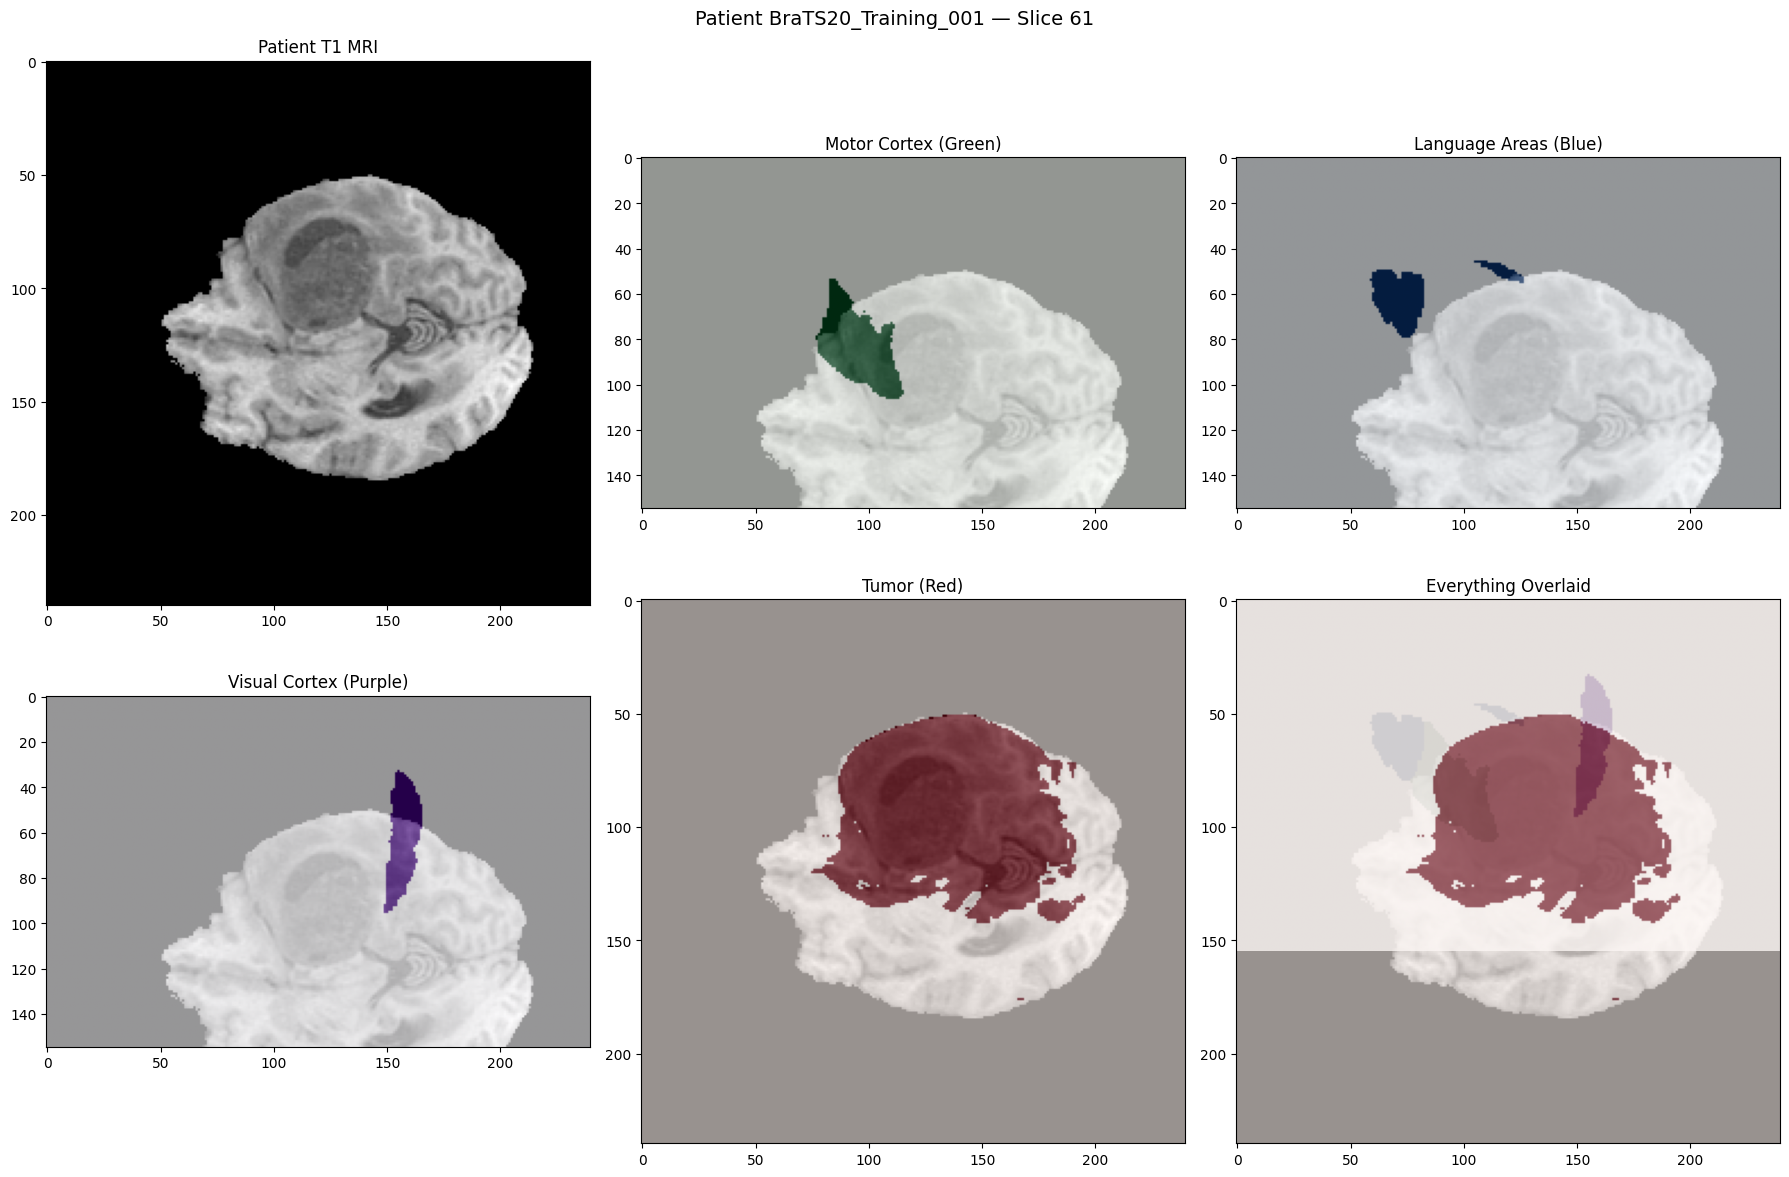

Saved to /kaggle/working/step5_visualization.png


In [194]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

# Load patient T1 as background
t1_data = nib.load(f"{patient_dir}/{patient_id}_t1.nii").get_fdata()

# Find best slice — where tumor is largest
slice_idx = np.argmax(np.sum(whole_tumor, axis=(0, 1)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ── Row 1: Individual masks ───────────────────────────────────────
# T1 alone
axes[0,0].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[0,0].set_title('Patient T1 MRI', fontsize=12)

# Motor cortex
axes[0,1].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[0,1].imshow(motor_mask_patient[:, :, slice_idx], 
                  cmap='Greens', alpha=0.6, vmin=0, vmax=1)
axes[0,1].set_title('Motor Cortex (Green)', fontsize=12)

# Language areas
axes[0,2].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[0,2].imshow(language_mask_patient[:, :, slice_idx], 
                  cmap='Blues', alpha=0.6, vmin=0, vmax=1)
axes[0,2].set_title('Language Areas (Blue)', fontsize=12)

# ── Row 2: Combined view ──────────────────────────────────────────
# Visual cortex
axes[1,0].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[1,0].imshow(visual_mask_patient[:, :, slice_idx], 
                  cmap='Purples', alpha=0.6, vmin=0, vmax=1)
axes[1,0].set_title('Visual Cortex (Purple)', fontsize=12)

# Tumor alone
axes[1,1].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[1,1].imshow(whole_tumor[:, :, slice_idx], 
                  cmap='Reds', alpha=0.6, vmin=0, vmax=1)
axes[1,1].set_title('Tumor (Red)', fontsize=12)

# Everything overlaid together
axes[1,2].imshow(t1_data[:, :, slice_idx], cmap='gray')
axes[1,2].imshow(motor_mask_patient[:, :, slice_idx],
                  cmap='Greens',  alpha=0.4, vmin=0, vmax=1)
axes[1,2].imshow(language_mask_patient[:, :, slice_idx],
                  cmap='Blues',   alpha=0.4, vmin=0, vmax=1)
axes[1,2].imshow(visual_mask_patient[:, :, slice_idx],
                  cmap='Purples', alpha=0.4, vmin=0, vmax=1)
axes[1,2].imshow(whole_tumor[:, :, slice_idx],
                  cmap='Reds',    alpha=0.6, vmin=0, vmax=1)
axes[1,2].set_title('Everything Overlaid', fontsize=12)

plt.suptitle(f'Patient {patient_id} — Slice {slice_idx}', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/step5_visualization.png', dpi=150)
plt.show()
print("Saved to /kaggle/working/step5_visualization.png")

In [195]:
# ── Fix axis order mismatch (functional masks saved transposed) ───
# tumor/edema masks : (240, 240, 155)  ← correct BraTS order
# motor/lang/visual : (155, 240, 240)  ← saved transposed in Step 5

print("\n   Fixing axis order for functional masks...")

motor_mask    = np.transpose(motor_mask,    (2, 1, 0))   # (155,240,240) → (240,240,155)
language_mask = np.transpose(language_mask, (2, 1, 0))
visual_mask   = np.transpose(visual_mask,   (2, 1, 0))

print(f"   motor_mask    after fix: {motor_mask.shape}")
print(f"   language_mask after fix: {language_mask.shape}")
print(f"   visual_mask   after fix: {visual_mask.shape}")

# ── Also fix the saved .npy files so Step 7+ never hits this again ──
np.save(BASE + 'motor_mask.npy',    motor_mask)
np.save(BASE + 'language_mask.npy', language_mask)
np.save(BASE + 'visual_mask.npy',   visual_mask)
print("\n✅ Fixed masks re-saved to disk (Step 7+ will load correctly)")


   Fixing axis order for functional masks...
   motor_mask    after fix: (240, 240, 155)
   language_mask after fix: (240, 240, 155)
   visual_mask   after fix: (240, 240, 155)

✅ Fixed masks re-saved to disk (Step 7+ will load correctly)


STEP 6: RISK MAP CREATION
✅ All masks loaded

   Shape check (expected (240, 240, 155)):
   ✅  tumor_mask       (240, 240, 155)  |  voxels:  917,893
   ✅  et_mask          (240, 240, 155)  |  voxels:   81,983
   ✅  edema_mask       (240, 240, 155)  |  voxels:  307,808
   ✅  whole_tumor      (240, 240, 155)  |  voxels:  446,119
   ✅  motor_mask       (240, 240, 155)  |  voxels:  137,231
   ✅  language_mask    (240, 240, 155)  |  voxels:   27,663
   ✅  visual_mask      (240, 240, 155)  |  voxels:  111,018

   Normal tissue voxels :  8,235,681
   Functional union     :    275,912

✅ Risk weights defined:
   Motor cortex   : 0.95
   Language areas : 0.95
   Visual cortex  : 0.8
   Edema          : 0.5
   Normal tissue  : 0.1
   Tumor target   : 0.0


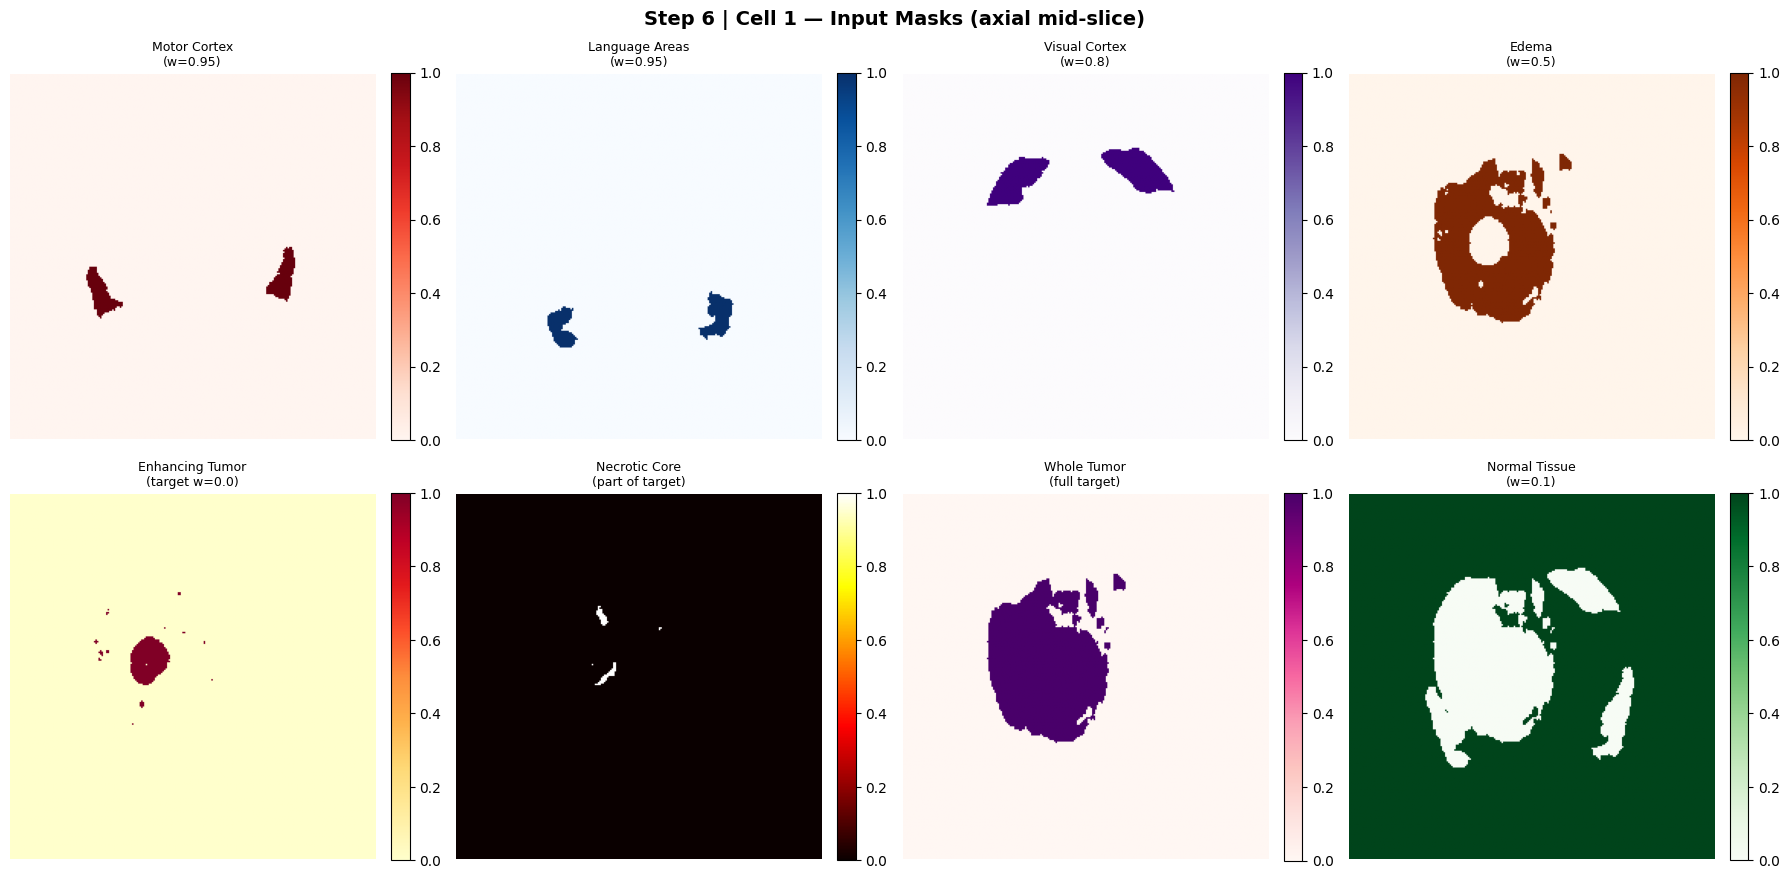


✅ Preview saved → step6_cell1_input_masks.png
▶  Ready for Cell 2: Compose risk map


In [196]:
# ============================================================
# STEP 6 — RISK MAP CREATION
# Cell 1: Load All Masks & Define Risk Weights
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 6: RISK MAP CREATION")
print("=" * 60)

BASE  = '/kaggle/working/'
SHAPE = (240, 240, 155)

# ── Load all masks ────────────────────────────────────────────
tumor_mask    = np.load(BASE + 'tumor_mask.npy')
et_mask       = np.load(BASE + 'et_mask.npy')
ncr_mask      = np.load(BASE + 'ncr_mask.npy')
edema_mask    = np.load(BASE + 'edema_mask.npy')
whole_tumor   = np.load(BASE + 'whole_tumor.npy')
motor_mask    = np.load(BASE + 'motor_mask.npy')
language_mask = np.load(BASE + 'language_mask.npy')
visual_mask   = np.load(BASE + 'visual_mask.npy')

print("✅ All masks loaded")
print(f"\n   Shape check (expected {SHAPE}):")
for name, m in [('tumor_mask',    tumor_mask),
                ('et_mask',       et_mask),
                ('edema_mask',    edema_mask),
                ('whole_tumor',   whole_tumor),
                ('motor_mask',    motor_mask),
                ('language_mask', language_mask),
                ('visual_mask',   visual_mask)]:
    match = '✅' if m.shape == SHAPE else '✗ MISMATCH'
    print(f"   {match}  {name:<16} {m.shape}  |  voxels: {int(m.sum()):>8,}")

# ── Binarize all masks (safe: force clean 0/1 float32) ────────
motor_bin    = (motor_mask    > 0).astype(np.float32)
language_bin = (language_mask > 0).astype(np.float32)
visual_bin   = (visual_mask   > 0).astype(np.float32)
edema_bin    = (edema_mask    > 0).astype(np.float32)
et_bin       = (et_mask       > 0).astype(np.float32)
ncr_bin      = (ncr_mask      > 0).astype(np.float32)
whole_bin    = (whole_tumor   > 0).astype(np.float32)

# ── Derive normal tissue mask ─────────────────────────────────
# = everything that is NOT tumor AND NOT any functional region
functional_union = np.clip(motor_bin + language_bin + visual_bin, 0, 1)
normal_tissue    = ((functional_union == 0) & (whole_bin == 0)).astype(np.float32)

print(f"\n   Normal tissue voxels : {int(normal_tissue.sum()):>10,}")
print(f"   Functional union     : {int(functional_union.sum()):>10,}")

# ── Risk weights ──────────────────────────────────────────────
W_MOTOR    = 0.95   # near-absolute barrier — permanent deficit
W_LANGUAGE = 0.95   # near-absolute barrier — permanent deficit
W_VISUAL   = 0.80   # high risk — serious deficit
W_EDEMA    = 0.50   # medium-high — inflamed, bleeds easily
W_NORMAL   = 0.10   # small traversal cost
W_TARGET   = 0.00   # tumor = destination, zero cost

print("\n✅ Risk weights defined:")
print(f"   Motor cortex   : {W_MOTOR}")
print(f"   Language areas : {W_LANGUAGE}")
print(f"   Visual cortex  : {W_VISUAL}")
print(f"   Edema          : {W_EDEMA}")
print(f"   Normal tissue  : {W_NORMAL}")
print(f"   Tumor target   : {W_TARGET}")

# ── Quick axial preview of all input masks ────────────────────
mid_z = SHAPE[2] // 2

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Step 6 | Cell 1 — Input Masks (axial mid-slice)", 
             fontsize=14, fontweight='bold')

panels = [
    (motor_bin,    'Reds',    f'Motor Cortex\n(w={W_MOTOR})'),
    (language_bin, 'Blues',   f'Language Areas\n(w={W_LANGUAGE})'),
    (visual_bin,   'Purples', f'Visual Cortex\n(w={W_VISUAL})'),
    (edema_bin,    'Oranges', f'Edema\n(w={W_EDEMA})'),
    (et_bin,       'YlOrRd',  f'Enhancing Tumor\n(target w={W_TARGET})'),
    (ncr_bin,      'hot',     f'Necrotic Core\n(part of target)'),
    (whole_bin,    'RdPu',    f'Whole Tumor\n(full target)'),
    (normal_tissue,'Greens',  f'Normal Tissue\n(w={W_NORMAL})'),
]

for ax, (mask, cmap, title) in zip(axes.flat, panels):
    sl = mask[:, :, mid_z]
    im = ax.imshow(sl.T, origin='lower', cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(BASE + 'step6_cell1_input_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Preview saved → step6_cell1_input_masks.png")
print("▶  Ready for Cell 2: Compose risk map")

In [197]:
# ============================================================
# STEP 6 — RISK MAP CREATION
# Cell 2: Compose 3D Risk Map (Hard Boundaries)
# ============================================================

print("=" * 60)
print("STEP 6 | Cell 2: Composing Risk Map")
print("=" * 60)

# ── Build risk map layer by layer (priority order) ────────────
# Lower priority layers are placed first, higher ones overwrite.
# Tumor target is always last — guaranteed zero cost at destination.
#
# Priority (low → high):
#   normal tissue → edema → visual → language → motor → tumor

risk_map = np.zeros(SHAPE, dtype=np.float32)

risk_map = np.where(normal_tissue > 0, W_NORMAL,   risk_map)
risk_map = np.where(edema_bin     > 0, W_EDEMA,    risk_map)
risk_map = np.where(visual_bin    > 0, W_VISUAL,   risk_map)
risk_map = np.where(language_bin  > 0, W_LANGUAGE, risk_map)
risk_map = np.where(motor_bin     > 0, W_MOTOR,    risk_map)
risk_map = np.where(whole_bin     > 0, W_TARGET,   risk_map)  # always last

print("✅ Risk map composed (hard boundaries, layered priority)")
print(f"   Shape : {risk_map.shape}")
print(f"   Min   : {risk_map.min():.4f}")
print(f"   Max   : {risk_map.max():.4f}")
print(f"   Mean  : {risk_map.mean():.4f}")

# ── Voxel count per risk tier ─────────────────────────────────
print("\n   Voxel distribution by risk tier:")
tiers = [
    (0.00, 0.00, 'Zero  (tumor target)  '),
    (0.01, 0.10, 'Low   (normal tissue) '),
    (0.11, 0.50, 'Med   (edema)         '),
    (0.51, 0.80, 'High  (visual)        '),
    (0.81, 1.00, 'Critical (motor/lang) '),
]
total = risk_map.size
for lo, hi, label in tiers:
    count = int(((risk_map >= lo) & (risk_map <= hi)).sum())
    pct   = 100 * count / total
    bar   = '█' * int(pct / 2)
    print(f"   {label} : {count:>10,}  ({pct:5.1f}%)  {bar}")

# ── Save ──────────────────────────────────────────────────────
np.save(BASE + 'risk_map_3d.npy', risk_map)
print(f"\n✅ Saved → {BASE}risk_map_3d.npy")
print("▶  Ready for Cell 3: Visualize risk map")

STEP 6 | Cell 2: Composing Risk Map
✅ Risk map composed (hard boundaries, layered priority)
   Shape : (240, 240, 155)
   Min   : 0.0000
   Max   : 0.9500
   Mean  : 0.1170

   Voxel distribution by risk tier:
   Zero  (tumor target)   :    446,119  (  5.0%)  ██
   Low   (normal tissue)  :  8,235,681  ( 92.2%)  ██████████████████████████████████████████████
   Med   (edema)          :          0  (  0.0%)  
   High  (visual)         :     86,200  (  1.0%)  
   Critical (motor/lang)  :    160,000  (  1.8%)  

✅ Saved → /kaggle/working/risk_map_3d.npy
▶  Ready for Cell 3: Visualize risk map


STEP 6 | Cell 3: Visualizing Risk Map
⚠  T1 not found — showing risk map alone
   Tumor centroid slice → axial=61, coronal=139, sagittal=97


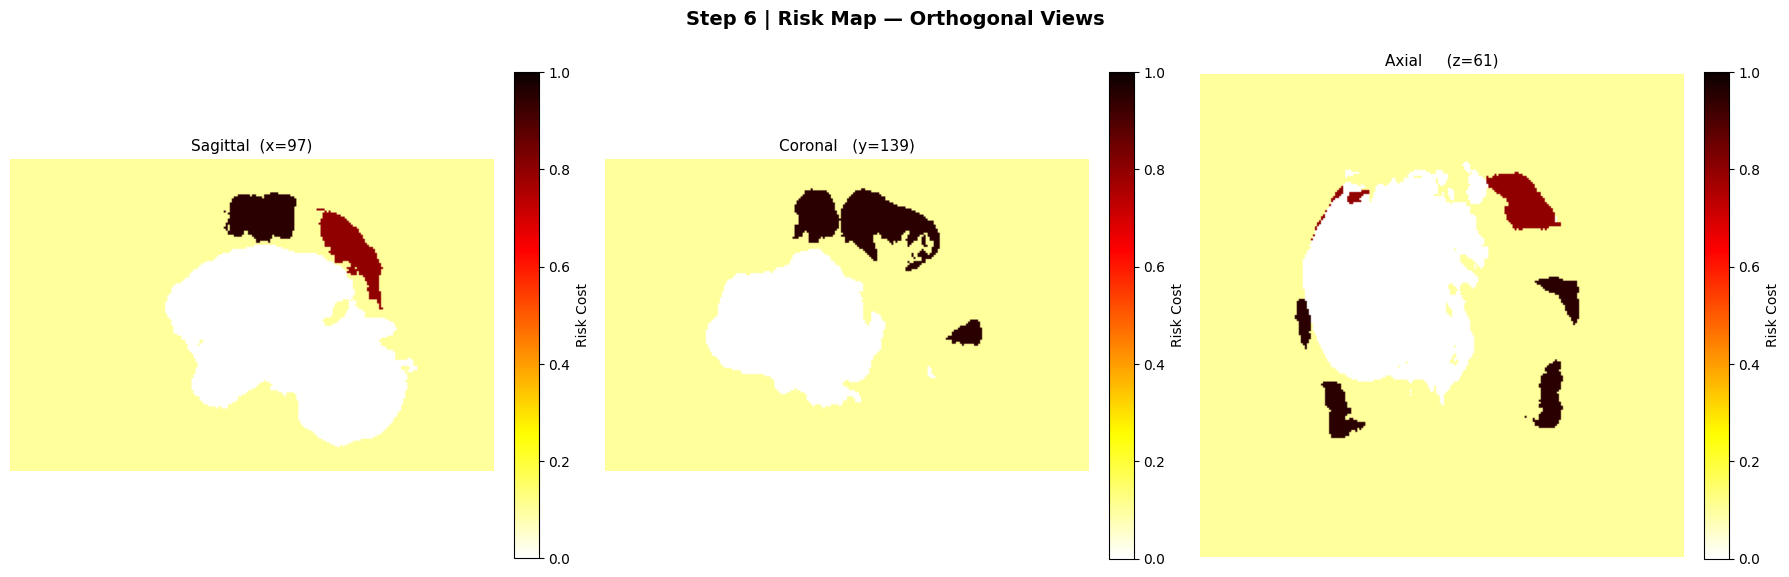

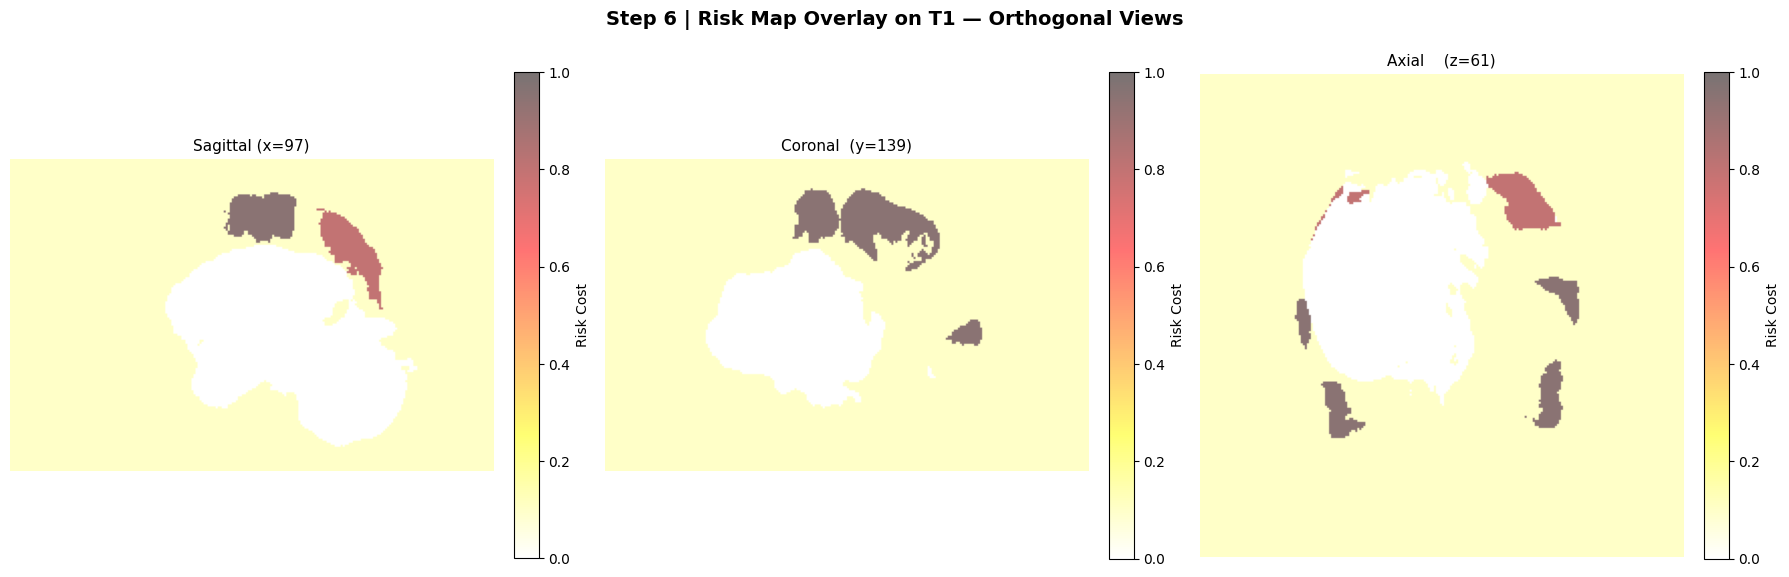

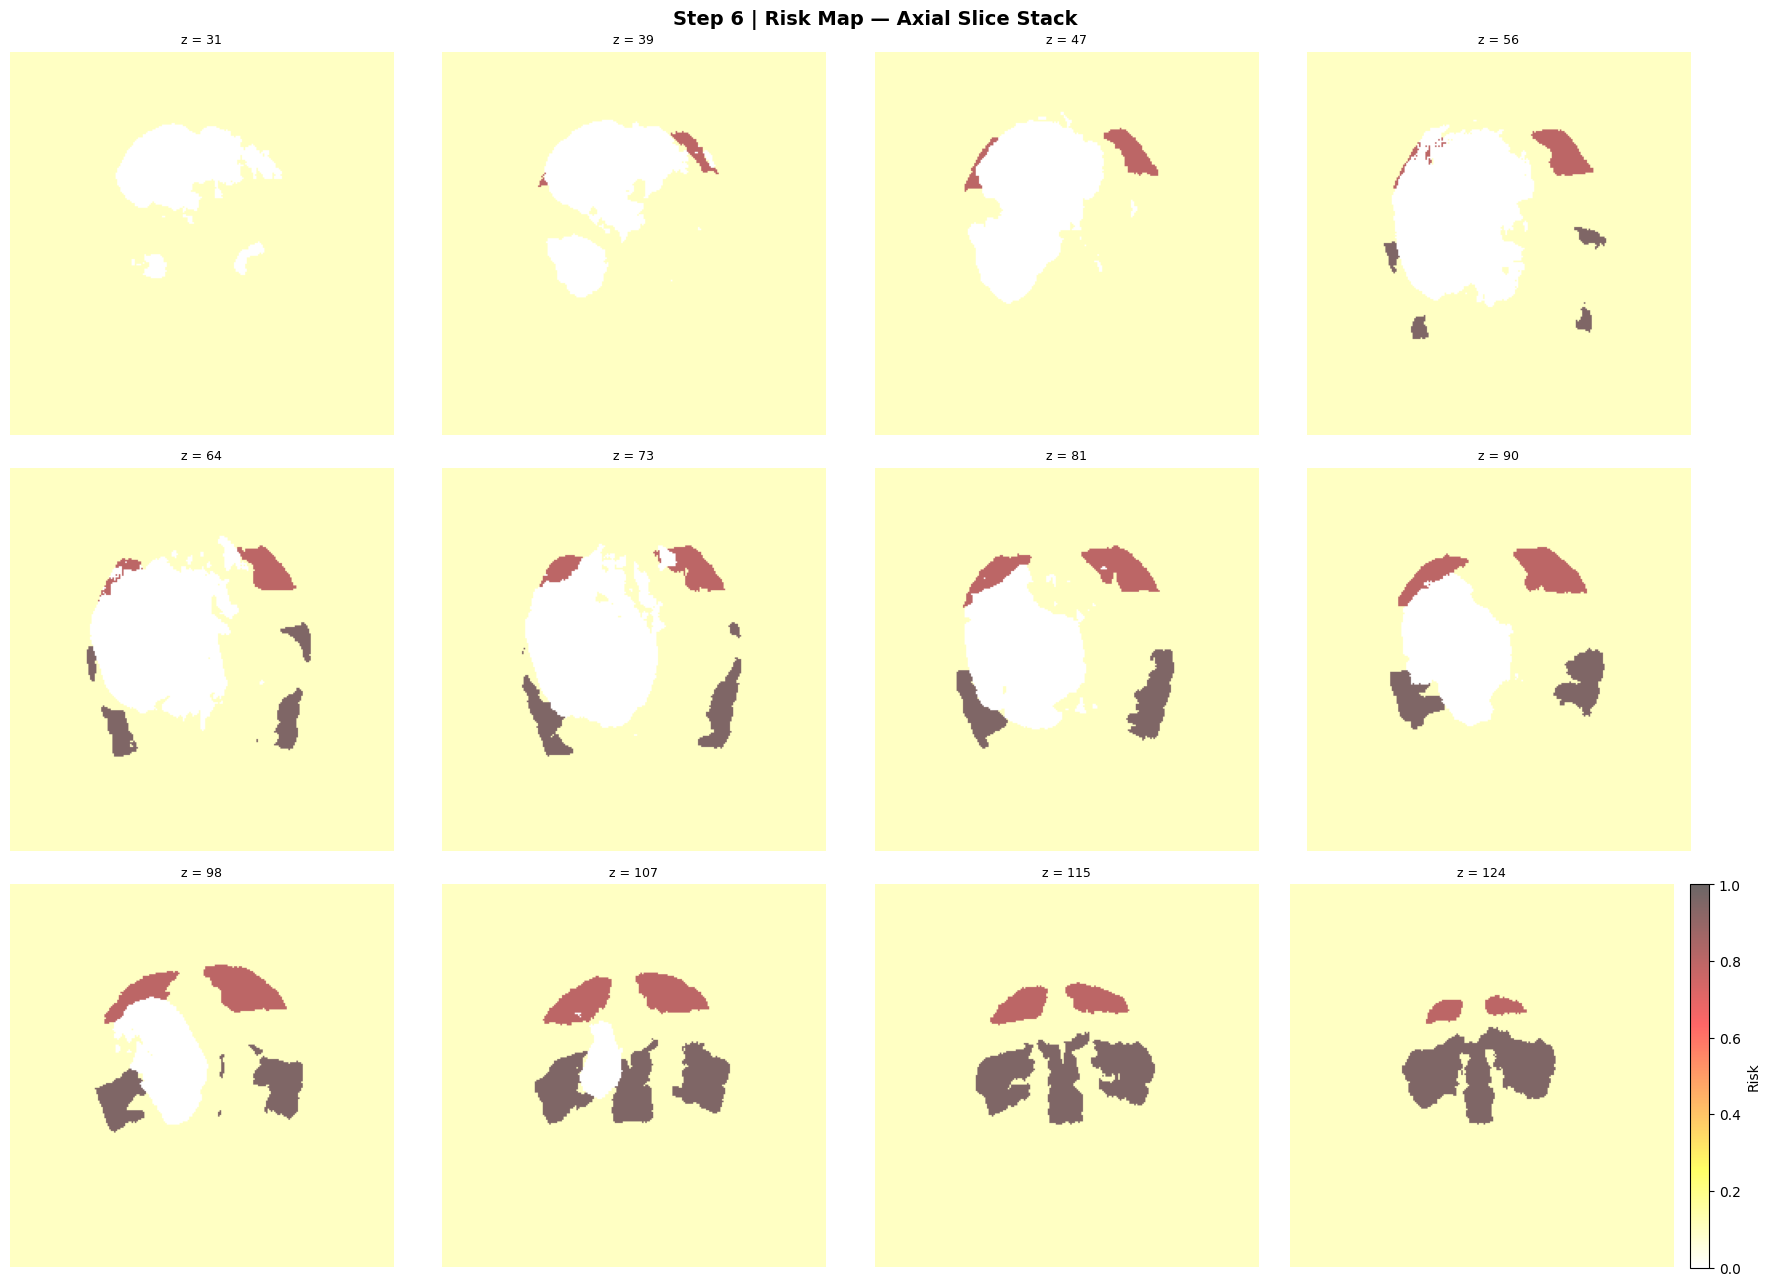


✅ All visualizations saved:
   → step6_cell3_riskmap_orthogonal.png
   → step6_cell3_riskmap_overlay.png
   → step6_cell3_riskmap_axialstack.png

✅ STEP 6 COMPLETE
   risk_map_3d.npy is ready for Step 7 (Candidate Entry Points)


In [198]:
# ============================================================
# STEP 6 — RISK MAP CREATION
# Cell 3: Visualize Risk Map (3 planes + overlay)
# ============================================================

print("=" * 60)
print("STEP 6 | Cell 3: Visualizing Risk Map")
print("=" * 60)

# ── Load T1 for anatomical background ─────────────────────────
import nibabel as nib
import os

t1_path = (
    '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/'
    'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'
    'BraTS20_Training_001/BraTS20_Training_001_t1.nii.gz'
)

if os.path.exists(t1_path):
    t1_data = nib.load(t1_path).get_fdata()
    # Normalize T1 to [0,1] for display
    t1_data = (t1_data - t1_data.min()) / (t1_data.max() - t1_data.min() + 1e-8)
    has_t1  = True
    print("✅ T1 loaded for background")
else:
    has_t1  = False
    print("⚠  T1 not found — showing risk map alone")

# ── Pick representative slices ────────────────────────────────
# Use tumor centroid slice so the tumor is always visible
tumor_voxels = np.argwhere(whole_bin > 0)
if len(tumor_voxels) > 0:
    cx, cy, cz = tumor_voxels.mean(axis=0).astype(int)
else:
    cx, cy, cz = [s // 2 for s in SHAPE]

print(f"   Tumor centroid slice → axial={cz}, coronal={cy}, sagittal={cx}")

# ── Figure 1: Three orthogonal planes of risk map ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Step 6 | Risk Map — Orthogonal Views", 
             fontsize=14, fontweight='bold')

planes = [
    (risk_map[cx, :, :].T,  f'Sagittal  (x={cx})'),
    (risk_map[:, cy, :].T,  f'Coronal   (y={cy})'),
    (risk_map[:, :, cz].T,  f'Axial     (z={cz})'),
]

for ax, (sl, title) in zip(axes, planes):
    im = ax.imshow(sl, origin='lower', cmap='hot_r', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Risk Cost')

plt.tight_layout()
plt.savefig(BASE + 'step6_cell3_riskmap_orthogonal.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Risk map overlaid on T1 ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Step 6 | Risk Map Overlay on T1 — Orthogonal Views",
             fontsize=14, fontweight='bold')

bg_planes = [
    (t1_data[cx, :, :].T  if has_t1 else np.zeros((SHAPE[1], SHAPE[2])),
     risk_map[cx, :, :].T, f'Sagittal (x={cx})'),
    (t1_data[:, cy, :].T  if has_t1 else np.zeros((SHAPE[0], SHAPE[2])),
     risk_map[:, cy, :].T, f'Coronal  (y={cy})'),
    (t1_data[:, :, cz].T  if has_t1 else np.zeros((SHAPE[0], SHAPE[1])),
     risk_map[:, :, cz].T, f'Axial    (z={cz})'),
]

for ax, (bg, risk_sl, title) in zip(axes, bg_planes):
    if has_t1:
        ax.imshow(bg,      origin='lower', cmap='gray',  alpha=1.0)
    im = ax.imshow(risk_sl, origin='lower', cmap='hot_r',
                   alpha=0.55, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Risk Cost')

plt.tight_layout()
plt.savefig(BASE + 'step6_cell3_riskmap_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Multi-slice axial stack ─────────────────────────
n_slices = 12
z_slices = np.linspace(SHAPE[2] * 0.2, SHAPE[2] * 0.8, n_slices).astype(int)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle("Step 6 | Risk Map — Axial Slice Stack", 
             fontsize=14, fontweight='bold')

for ax, z in zip(axes.flat, z_slices):
    if has_t1:
        ax.imshow(t1_data[:, :, z].T, origin='lower', cmap='gray')
    im = ax.imshow(risk_map[:, :, z].T, origin='lower',
                   cmap='hot_r', alpha=0.6, vmin=0, vmax=1)
    ax.set_title(f'z = {z}', fontsize=9)
    ax.axis('off')

plt.colorbar(im, ax=axes.flat[-1], fraction=0.046, pad=0.04, label='Risk')
plt.tight_layout()
plt.savefig(BASE + 'step6_cell3_riskmap_axialstack.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations saved:")
print("   → step6_cell3_riskmap_orthogonal.png")
print("   → step6_cell3_riskmap_overlay.png")
print("   → step6_cell3_riskmap_axialstack.png")
print("\n✅ STEP 6 COMPLETE")
print("   risk_map_3d.npy is ready for Step 7 (Candidate Entry Points)")

****CONVERTING THE 3D MAP.npy to VTK****


In [199]:
# # ============================================================
# # STEP 6 — RISK MAP CREATION
# # Cell 4: Export Risk Map to VTK (for 3D Slicer)
# # ============================================================

# import numpy as np
# import pyvista as pv

# print("=" * 60)
# print("STEP 6 | Cell 4: Exporting Risk Map to VTK")
# print("=" * 60)

# BASE = '/kaggle/working/'

# # ── Load risk map ────────────────────────────────────────────
# risk_map = np.load(BASE + 'risk_map_3d.npy')
# print(f"✅ Risk map loaded: {risk_map.shape}")

# # ── Create PyVista grid (IMPORTANT: order & spacing) ─────────
# # VTK expects (x, y, z) ordering — your array is already correct

# grid = pv.ImageData()

# # Set dimensions (NOTE: +1 is NOT needed for ImageData)
# grid.dimensions = risk_map.shape

# # Optional: set spacing (voxel size in mm)
# # BraTS is typically 1mm isotropic
# grid.spacing = (1.0, 1.0, 1.0)

# # Optional: set origin
# grid.origin = (0, 0, 0)

# # ── Flatten and assign data ──────────────────────────────────
# # IMPORTANT: Fortran order ('F') is required for correct orientation
# grid.point_data["risk"] = risk_map.flatten(order="F")

# print("✅ Grid created and data assigned")

# # ── Save as VTK ──────────────────────────────────────────────
# vtk_path = BASE + 'risk_map.vtk'
# grid.save(vtk_path)

# print(f"\n✅ Saved VTK file → {vtk_path}")
# print("▶  Download this file and open in 3D Slicer")

In [200]:
# ============================================================
# STEP 7 — CANDIDATE ENTRY POINTS
# Cell 1: Load data & define entry point strategy
# ============================================================

import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage import morphology, measure
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("  STEP 7: CANDIDATE ENTRY POINTS")
print("=" * 60)

# ── 1. Load all required maps ────────────────────────────────
risk_map      = np.load('/kaggle/working/risk_map_3d.npy')
whole_tumor   = np.load('/kaggle/working/whole_tumor.npy').astype(bool)
et_mask       = np.load('/kaggle/working/et_mask.npy').astype(bool)
edema_mask    = np.load('/kaggle/working/edema_mask.npy').astype(bool)
motor_mask    = np.load('/kaggle/working/motor_mask.npy').astype(bool)
language_mask = np.load('/kaggle/working/language_mask.npy').astype(bool)
visual_mask   = np.load('/kaggle/working/visual_mask.npy').astype(bool)

print(f"✅ risk_map      : shape={risk_map.shape},  min={risk_map.min():.3f}, max={risk_map.max():.3f}")
print(f"✅ whole_tumor   : voxels={whole_tumor.sum()}")
print(f"✅ et_mask       : voxels={et_mask.sum()}")
print(f"✅ edema_mask    : voxels={edema_mask.sum()}")
print(f"✅ motor_mask    : voxels={motor_mask.sum()}")
print(f"✅ language_mask : voxels={language_mask.sum()}")
print(f"✅ visual_mask   : voxels={visual_mask.sum()}")

# ── 2. Load NIfTI for voxel-to-mm affine ────────────────────
patient_id  = 'BraTS20_Training_001'
data_root   = f'/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/{patient_id}'
t1ce_nii    = nib.load(f'{data_root}/{patient_id}_t1ce.nii')

affine      = t1ce_nii.affine
voxel_size  = np.abs(np.diag(affine)[:3])          # mm per voxel

print(f"\n📐 Affine voxel size : {voxel_size} mm")
print(f"📐 Volume shape      : {risk_map.shape}")

# ── 3. Derive surgical target (centroid of ET) ───────────────
if et_mask.sum() > 0:
    et_coords  = np.array(np.where(et_mask)).T      # (N,3)
    target_vox = et_coords.mean(axis=0).astype(int)
else:
    # Fall back to whole-tumor centroid
    wt_coords  = np.array(np.where(whole_tumor)).T
    target_vox = wt_coords.mean(axis=0).astype(int)
    print("⚠️  ET mask empty — using whole-tumor centroid as target")

target_mm = nib.affines.apply_affine(affine, target_vox)
print(f"\n🎯 Surgical target  : voxel={target_vox}  |  mm={np.round(target_mm,1)}")

# ── 4. Define scalp surface for entry point search ──────────────
# Brain boundary ≈ outermost non-zero voxels of the volume
#   We build a "brain mask" = any voxel that has non-background
#   signal by thresholding the T1ce image itself.
t1ce_data = t1ce_nii.get_fdata()
brain_mask = t1ce_data > t1ce_data.mean() * 0.15   # loose threshold

# Erode once to get interior, surface = mask XOR interior
brain_interior = ndimage.binary_erosion(brain_mask, iterations=3)
brain_surface  = brain_mask & ~brain_interior
surface_voxels = np.array(np.where(brain_surface)).T

print(f"\n🧠 Brain surface voxels : {len(surface_voxels)}")
print(f"   (These are the candidate entry-point pool)")

# ── 5. Quick orientation summary ────────────────────────────────
print("\n" + "─" * 60)
print("STRATEGY OVERVIEW")
print("─" * 60)
print("""
  Entry point scoring considers 3 criteria:

  [A] PATH LENGTH        → prefer shorter trajectories
                           (Euclidean distance: surface → target)

  [B] RISK ALONG PATH    → prefer paths that avoid eloquent cortex
                           (motor / language / visual masks)
                           sampled by casting a ray from surface→target

  [C] TRAJECTORY ANGLE   → prefer near-perpendicular skull entry
                           (avoids skimming cortex surface)

  Scoring formula (per candidate):
    score = w_len  * norm(length)
           + w_risk * norm(mean_risk_along_ray)
           + w_ang  * norm(angle_penalty)

  Lower score  →  better candidate.
  Top-K candidates saved for Step 8 (A* path planning).
""")
print("=" * 60)
print("✅ Cell 1 complete — ready for Cell 2 (scoring & ranking)")
print("=" * 60)

  STEP 7: CANDIDATE ENTRY POINTS
✅ risk_map      : shape=(240, 240, 155),  min=0.000, max=0.950
✅ whole_tumor   : voxels=446119
✅ et_mask       : voxels=81983
✅ edema_mask    : voxels=307808
✅ motor_mask    : voxels=137231
✅ language_mask : voxels=27663
✅ visual_mask   : voxels=111018

📐 Affine voxel size : [1. 1. 1.] mm
📐 Volume shape      : (240, 240, 155)

🎯 Surgical target  : voxel=[ 94 151  50]  |  mm=[-94.  88.  50.]

🧠 Brain surface voxels : 169984
   (These are the candidate entry-point pool)

────────────────────────────────────────────────────────────
STRATEGY OVERVIEW
────────────────────────────────────────────────────────────

  Entry point scoring considers 3 criteria:

  [A] PATH LENGTH        → prefer shorter trajectories
                           (Euclidean distance: surface → target)

  [B] RISK ALONG PATH    → prefer paths that avoid eloquent cortex
                           (motor / language / visual masks)
                           sampled by casting a ray from 

Saved as visualization.png


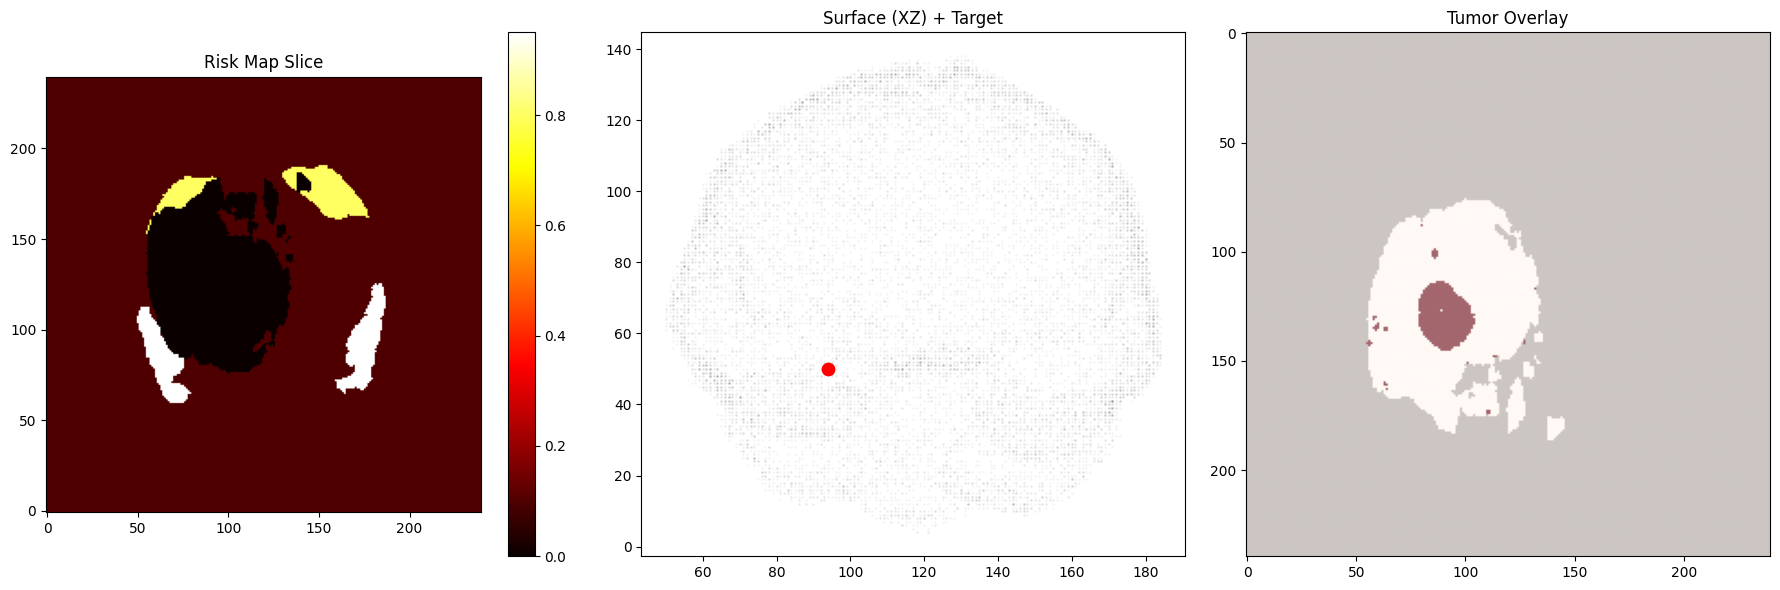

In [201]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# rebuild minimal required data
t1ce = t1ce_nii.get_fdata()

if et_mask.sum() > 0:
    et_coords = np.array(np.where(et_mask)).T
    target_vox = et_coords.mean(axis=0).astype(int)
else:
    wt_coords = np.array(np.where(whole_tumor)).T
    target_vox = wt_coords.mean(axis=0).astype(int)

brain_mask = t1ce > t1ce.mean() * 0.15
brain_interior = ndimage.binary_erosion(brain_mask, iterations=3)
brain_surface = brain_mask & ~brain_interior

surface_vox = np.array(np.where(brain_surface)).T
if len(surface_vox) > 15000:
    surface_vox = surface_vox[np.random.choice(len(surface_vox), 15000, replace=False)]

z = risk_map.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Risk map
im = axes[0].imshow(risk_map[:, :, z].T, cmap='hot', origin='lower')
axes[0].set_title("Risk Map Slice")
plt.colorbar(im, ax=axes[0])

# Surface + target (2D projection for reliability)
axes[1].scatter(surface_vox[:,0], surface_vox[:,2], s=1, alpha=0.05, c='gray')
axes[1].scatter(target_vox[0], target_vox[2], c='red', s=80)
axes[1].set_title("Surface (XZ) + Target")

# Tumor overlay
axes[2].imshow(whole_tumor[:, :, z].T, cmap='gray', alpha=0.5)
axes[2].imshow(et_mask[:, :, z].T, cmap='Reds', alpha=0.6)
axes[2].set_title("Tumor Overlay")
plt.savefig("visualization.png", dpi=200, bbox_inches='tight')
print("Saved as visualization.png")
plt.tight_layout()
plt.show()

In [202]:
# ============================================================
# STEP 8 — A* PATH PLANNING (Cell 1: Setup)
# ============================================================

import numpy as np
import nibabel as nib
from scipy import ndimage
import heapq

print("=" * 60)
print("STEP 8: A* PATH PLANNING - INITIALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load required data
# ------------------------------------------------------------
risk_map = np.load('/kaggle/working/risk_map_3d.npy')

whole_tumor = np.load('/kaggle/working/whole_tumor.npy').astype(bool)
et_mask     = np.load('/kaggle/working/et_mask.npy').astype(bool)

t1ce_path = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii"
t1ce_nii = nib.load(t1ce_path)

affine = t1ce_nii.affine
t1ce = t1ce_nii.get_fdata()

# ------------------------------------------------------------
# 2. Define surgical target (goal node)
# ------------------------------------------------------------
if et_mask.sum() > 0:
    et_coords = np.array(np.where(et_mask)).T
    target_vox = et_coords.mean(axis=0).astype(int)
else:
    wt_coords = np.array(np.where(whole_tumor)).T
    target_vox = wt_coords.mean(axis=0).astype(int)

target_vox = tuple(target_vox)

print(f"🎯 Target voxel: {target_vox}")

# ------------------------------------------------------------
# 3. Build brain surface (START candidates)
# ------------------------------------------------------------
brain_mask = t1ce > t1ce.mean() * 0.15
brain_interior = ndimage.binary_erosion(brain_mask, iterations=3)
brain_surface = brain_mask & ~brain_interior

surface_voxels = np.array(np.where(brain_surface)).T

# downsample for tractability
MAX_STARTS = 5000
if len(surface_voxels) > MAX_STARTS:
    idx = np.random.choice(len(surface_voxels), MAX_STARTS, replace=False)
    surface_voxels = surface_voxels[idx]

surface_voxels = [tuple(v) for v in surface_voxels]

print(f"🧠 Start candidates (skull surface): {len(surface_voxels)}")

# ------------------------------------------------------------
# 4. Movement model (6-connected grid)
# ------------------------------------------------------------
MOVES = [
    (1,0,0), (-1,0,0),
    (0,1,0), (0,-1,0),
    (0,0,1), (0,0,-1)
]

# ------------------------------------------------------------
# 5. Cost weights (tunable later)
# ------------------------------------------------------------
W_RISK = 1.0
W_LENGTH = 0.2

# ------------------------------------------------------------
# 6. Heuristic function (Euclidean distance)
# ------------------------------------------------------------
def heuristic(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# ------------------------------------------------------------
# 7. Node cost function
# ------------------------------------------------------------
def cost(voxel):
    x, y, z = voxel
    return risk_map[x, y, z]

print("=" * 60)
print("✅ A* initialization complete")
print("Next: Cell 2 → run full path search (A*)")
print("=" * 60)

STEP 8: A* PATH PLANNING - INITIALIZATION
🎯 Target voxel: (np.int64(94), np.int64(151), np.int64(50))
🧠 Start candidates (skull surface): 5000
✅ A* initialization complete
Next: Cell 2 → run full path search (A*)


In [215]:
# ============================================================
# STEP 8 — CELL 2: A* PATH SEARCH
# ============================================================

import numpy as np
import heapq

print("=" * 60)
print("STEP 8.2: RUNNING A* PATH SEARCH")
print("=" * 60)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def heuristic(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def in_bounds(v, shape):
    x, y, z = v
    return 0 <= x < shape[0] and 0 <= y < shape[1] and 0 <= z < shape[2]

# ------------------------------------------------------------
# A* search from one start point
# ------------------------------------------------------------
def astar(start, goal, risk_map, max_steps=5000):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    steps = 0

    while open_set and steps < max_steps:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # reconstruct path
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for dx, dy, dz in MOVES:
            neighbor = (current[0]+dx, current[1]+dy, current[2]+dz)

            if not in_bounds(neighbor, risk_map.shape):
                continue

            # cost = movement + risk penalty
            tentative_g = g_score[current] + 1 + W_RISK * risk_map[neighbor]

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

        steps += 1

    return None

# ------------------------------------------------------------
# Run A* from subset of entry points (IMPORTANT for speed)
# ------------------------------------------------------------
NUM_STARTS = 50  # keep small for Kaggle stability
selected_starts = surface_voxels[:NUM_STARTS]

all_paths = []

print(f"🚀 Running A* on {NUM_STARTS} entry points...")

for i, start in enumerate(selected_starts):
    path = astar(start, target_vox, risk_map)

    

    if path is not None:
        all_paths.append(path)

    if i % 10 == 0:
        print(f"  processed {i}/{NUM_STARTS}")

# ------------------------------------------------------------
# Result summary (FIXED)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 8.2 RESULTS SUMMARY")
print("=" * 60)

print(f"✅ Total successful paths: {len(all_paths)}")

if len(all_paths) == 0:
    print("❌ No valid paths found")
else:
    # temporarily pick best by length (for now)

    print("\n🏆 BEST PATH (TEMP SELECTION)")
    print(f"📏 Path length: {len(best_path)} voxels")
    print(f"🎯 Start: {best_path[0]}")
    print(f"🏁 End: {best_path[-1]}")

STEP 8.2: RUNNING A* PATH SEARCH
🚀 Running A* on 50 entry points...
  processed 0/50
  processed 10/50
  processed 20/50
  processed 30/50
  processed 40/50

STEP 8.2 RESULTS SUMMARY
✅ Total successful paths: 2

🏆 BEST PATH (TEMP SELECTION)
📏 Path length: 34 voxels
🎯 Start: (np.int64(70), np.int64(154), np.int64(44))
🏁 End: (np.int64(94), np.int64(151), np.int64(50))


STEP 8.3: VISUALIZING A* PATH


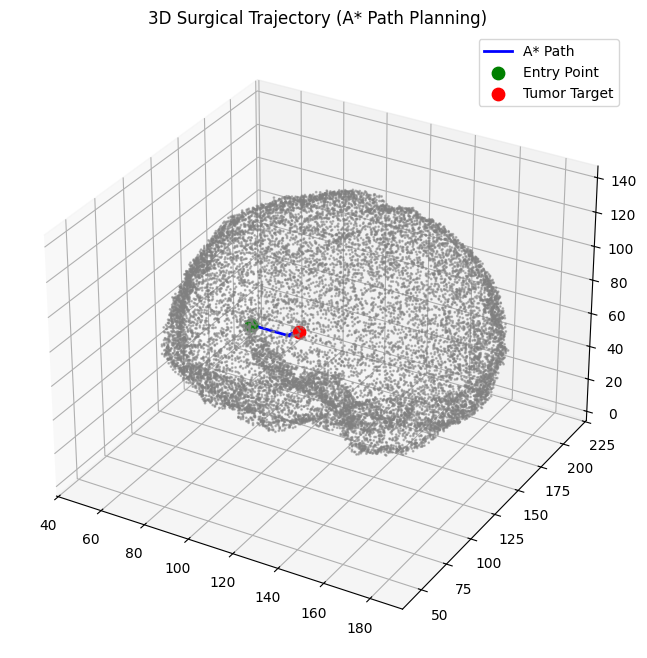

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

print("=" * 60)
print("STEP 8.3: VISUALIZING A* PATH")
print("=" * 60)

# ------------------------------------------------------------
# Rebuild brain surface (for context)
# ------------------------------------------------------------
brain_mask = t1ce > t1ce.mean() * 0.15
brain_interior = ndimage.binary_erosion(brain_mask, iterations=3)
brain_surface = brain_mask & ~brain_interior
surface_vox = np.array(np.where(brain_surface)).T

# downsample for visualization
if len(surface_vox) > 15000:
    idx = np.random.choice(len(surface_vox), 15000, replace=False)
    surface_vox = surface_vox[idx]

# ------------------------------------------------------------
# Convert path to array
# ------------------------------------------------------------
path = np.array(best_path)

entry = path[0]
target = path[-1]

# ------------------------------------------------------------
# 3D Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# brain surface (light gray)
ax.scatter(surface_vox[:,0], surface_vox[:,1], surface_vox[:,2],
           s=1, alpha=0.5, c='gray')

# full trajectory
ax.plot(path[:,0], path[:,1], path[:,2],
        c='blue', linewidth=2, label='A* Path')

# entry point
ax.scatter(entry[0], entry[1], entry[2],
           c='green', s=80, label='Entry Point')

# target
ax.scatter(target[0], target[1], target[2],
           c='red', s=80, label='Tumor Target')

ax.set_title("3D Surgical Trajectory (A* Path Planning)")
ax.legend()

plt.show()

In [213]:
# ============================================================
# STEP 9 — PATH SCORING & RANKING (Cell 1)
# ============================================================

import numpy as np

print("=" * 60)
print("STEP 9: PATH SCORING ENGINE")
print("=" * 60)

# ------------------------------------------------------------
# Weights (tunable clinically later)
# ------------------------------------------------------------
W_LENGTH = 0.2
W_RISK = 0.5
W_ELOQUENT = 0.3

# ------------------------------------------------------------
# Risk accumulation along path
# ------------------------------------------------------------
def compute_risk_score(path):
    return np.mean([risk_map[v] for v in path])

# ------------------------------------------------------------
# Eloquent cortex penalty
# ------------------------------------------------------------
def compute_eloquent_penalty(path):
    penalty = 0.0
    for v in path:
        if motor_mask[v] or language_mask[v] or visual_mask[v]:
            penalty += 1
    return penalty / len(path)

# ------------------------------------------------------------
# Path smoothness (turning angle approximation)
# ------------------------------------------------------------
def compute_smoothness(path):
    path = np.array(path)
    diffs = np.diff(path, axis=0)
    angles = np.linalg.norm(diffs, axis=1)
    return np.std(angles)

# ------------------------------------------------------------
# Length score
# ------------------------------------------------------------
def compute_length(path):
    return len(path)

# ------------------------------------------------------------
# Final scoring function
# (LOWER = BETTER)
# ------------------------------------------------------------
def score_path(path):
    length_score = compute_length(path)
    risk_score = compute_risk_score(path)
    eloquent_score = compute_eloquent_penalty(path)
    smoothness = compute_smoothness(path)

    total_score = (
        W_LENGTH * length_score +
        W_RISK * risk_score +
        W_ELOQUENT * eloquent_score +
        0.1 * smoothness
    )

    return total_score

print("✅ Scoring model ready")

STEP 9: PATH SCORING ENGINE
✅ Scoring model ready


In [217]:
# ============================================================
# STEP 9 — TRUE PATH RANKING
# ============================================================

print("=" * 60)
print("STEP 9.2: RANKING PATHS (MULTI-PATH)")
print("=" * 60)

# ------------------------------------------------------------
# IMPORTANT FIX: use all_paths, NOT best_path
# ------------------------------------------------------------
candidate_paths = all_paths

scored_paths = []

for i, path in enumerate(candidate_paths):
    score = score_path(path)
    scored_paths.append((score, path))

    print(f"Path {i}: score = {score:.4f}, length = {len(path)}")

# ------------------------------------------------------------
# Sort (LOWEST score = best)
# ------------------------------------------------------------
scored_paths.sort(key=lambda x: x[0])

print("\n==============================")
print("🏆 TOP RANKED PATHS")
print("==============================")

TOP_K = min(3, len(scored_paths))

for rank in range(TOP_K):
    score, path = scored_paths[rank]
    print(f"\nRank #{rank+1}")
    print(f"Score : {score:.4f}")
    print(f"Length: {len(path)}")
    print(f"Start : {path[0]}")
    print(f"End   : {path[-1]}")

# best path
best_score, best_ranked_path = scored_paths[0]

STEP 9.2: RANKING PATHS (MULTI-PATH)
Path 0: score = 7.4014, length = 37
Path 1: score = 6.8088, length = 34

🏆 TOP RANKED PATHS

Rank #1
Score : 6.8088
Length: 34
Start : (np.int64(70), np.int64(154), np.int64(44))
End   : (np.int64(94), np.int64(151), np.int64(50))

Rank #2
Score : 7.4014
Length: 37
Start : (np.int64(97), np.int64(151), np.int64(17))
End   : (np.int64(94), np.int64(151), np.int64(50))


In [222]:
import numpy as np
import plotly.graph_objects as go
from scipy import ndimage

print("=" * 60)
print("STEP 10: MULTI-PATH VISUALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Extract best 2 paths from Step 9 output
# ------------------------------------------------------------
best_path = scored_paths[0][1]
second_path = scored_paths[1][1]

best_path = np.array(best_path)
second_path = np.array(second_path)

entry1, entry2 = best_path[0], second_path[0]
target = best_path[-1]

# ------------------------------------------------------------
# Brain surface (downsample for performance)
# ------------------------------------------------------------
brain_mask = t1ce > t1ce.mean() * 0.2   # stronger threshold (less noise)

# keep only boundary shell
brain_interior = ndimage.binary_erosion(brain_mask, iterations=2)
brain_shell = brain_mask & ~brain_interior

surface = np.array(np.where(brain_shell)).T

# heavy downsample for clarity
if len(surface) > 8000:
    surface = surface[np.random.choice(len(surface), 8000, replace=False)]
# ------------------------------------------------------------
# Create Plotly figure
# ------------------------------------------------------------
fig = go.Figure()

# Brain surface
fig.add_trace(go.Scatter3d(
    x=surface[:,0],
    y=surface[:,1],
    z=surface[:,2],
    mode='markers',
    marker=dict(
        size=2,
        color='lightgray',
        opacity=0.25   # IMPORTANT: more visible now
    ),
    name='Brain Surface'
))
# ------------------------------------------------------------
# BEST PATH (green)
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=best_path[:,0], y=best_path[:,1], z=best_path[:,2],
    mode='lines',
    line=dict(color='green', width=6),
    name='Best Path (Rank #1)'
))

# ------------------------------------------------------------
# SECOND PATH (yellow)
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=second_path[:,0], y=second_path[:,1], z=second_path[:,2],
    mode='lines',
    line=dict(color='orange', width=6),
    name='Second Best Path (Rank #2)'
))

# ------------------------------------------------------------
# Entry points
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=[entry1[0]], y=[entry1[1]], z=[entry1[2]],
    mode='markers',
    marker=dict(size=6, color='green'),
    name='Entry Point #1'
))

fig.add_trace(go.Scatter3d(
    x=[entry2[0]], y=[entry2[1]], z=[entry2[2]],
    mode='markers',
    marker=dict(size=6, color='orange'),
    name='Entry Point #2'
))

# ------------------------------------------------------------
# Tumor target
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=[target[0]], y=[target[1]], z=[target[2]],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Tumor Target'
))

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
fig.update_layout(
    title="3D Surgical Path Planning - Top 2 Candidates",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    legend=dict(x=0, y=1)
)

# ------------------------------------------------------------
# Save interactive HTML
# ------------------------------------------------------------
output_file = "/kaggle/working/surgical_paths_top2.html"
fig.write_html(output_file)

print("✅ Saved interactive visualization:")
print(output_file)

fig.show()

STEP 10: MULTI-PATH VISUALIZATION
✅ Saved interactive visualization:
/kaggle/working/surgical_paths_top2.html


In [229]:
import numpy as np
import plotly.graph_objects as go
import pyvista as pv
from scipy import ndimage

print("=" * 70)
print("STEP 10: FULL INTEGRATED SURGICAL PLANNING VIEWER")
print("=" * 70)

# ============================================================
# 1. LOAD PATHS (from Step 9)
# ============================================================
best_path = np.array(scored_paths[0][1])
second_path = np.array(scored_paths[1][1]) if len(scored_paths) > 1 else None

target = best_path[-1]

# ============================================================
# 2. BRAIN SURFACE (clean + stable)
# ============================================================
brain_mask = t1ce > t1ce.mean() * 0.2
brain_interior = ndimage.binary_erosion(brain_mask, iterations=2)
brain_surface = brain_mask & ~brain_interior

surface = np.array(np.where(brain_surface)).T

if len(surface) > 8000:
    surface = surface[np.random.choice(len(surface), 8000, replace=False)]

# ============================================================
# 3. RISK MAP SAMPLING (for visualization only)
# ============================================================
risk_points = np.array(np.where(risk_map > 0.4)).T  # high-risk regions

if len(risk_points) > 5000:
    risk_points = risk_points[np.random.choice(len(risk_points), 5000, replace=False)]

# ============================================================
# 4. ATLAS REGIONS (motor/language/visual)
# ============================================================
motor_pts = np.array(np.where(motor_mask)).T
lang_pts = np.array(np.where(language_mask)).T
vis_pts = np.array(np.where(visual_mask)).T

def downsample(x, n=3000):
    if len(x) > n:
        return x[np.random.choice(len(x), n, replace=False)]
    return x

motor_pts = downsample(motor_pts)
lang_pts = downsample(lang_pts)
vis_pts = downsample(vis_pts)

# ============================================================
# 5. LOAD TUMOR MESHES (VTK via PyVista)
# ============================================================
try:
    tumor_mesh = pv.read("/kaggle/working/whole_tumor.vtk")
    et_mesh = pv.read("/kaggle/working/enhancing_tumor.vtk")
except:
    tumor_mesh = None
    et_mesh = None

# ============================================================
# 6. BUILD PLOTLY FIGURE
# ============================================================
fig = go.Figure()

# ------------------------------------------------------------
# Brain surface
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=surface[:,0], y=surface[:,1], z=surface[:,2],
    mode='markers',
    marker=dict(size=1.5, color='lightgray', opacity=1),
    name='Brain Surface'
))

# ------------------------------------------------------------
# Risk map (high-risk voxels)
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=risk_points[:,0], y=risk_points[:,1], z=risk_points[:,2],
    mode='markers',
    marker=dict(size=2, color='red', opacity=0.15),
    name='High Risk Zones'
))

# ------------------------------------------------------------
# Motor cortex
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=motor_pts[:,0], y=motor_pts[:,1], z=motor_pts[:,2],
    mode='markers',
    marker=dict(size=2, color='blue', opacity=0.25),
    name='Motor Cortex'
))

# ------------------------------------------------------------
# Language cortex
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=lang_pts[:,0], y=lang_pts[:,1], z=lang_pts[:,2],
    mode='markers',
    marker=dict(size=2, color='green', opacity=0.25),
    name='Language Cortex'
))

# ------------------------------------------------------------
# Visual cortex
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=vis_pts[:,0], y=vis_pts[:,1], z=vis_pts[:,2],
    mode='markers',
    marker=dict(size=2, color='purple', opacity=0.25),
    name='Visual Cortex'
))

# ------------------------------------------------------------
# BEST PATH (green)
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=best_path[:,0], y=best_path[:,1], z=best_path[:,2],
    mode='lines',
    line=dict(color='green', width=6),
    name='Best Surgical Path'
))

# ------------------------------------------------------------
# SECOND PATH (yellow)
# ------------------------------------------------------------
if second_path is not None:
    fig.add_trace(go.Scatter3d(
        x=second_path[:,0], y=second_path[:,1], z=second_path[:,2],
        mode='lines',
        line=dict(color='orange', width=6),
        name='Second Best Path'
    ))

# ------------------------------------------------------------
# TARGET (tumor center)
# ------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=[target[0]], y=[target[1]], z=[target[2]],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Tumor Target'
))

# ============================================================
# 7. LAYOUT
# ============================================================
fig.update_layout(
    title="Integrated 3D Surgical Planning System (Full View)",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    legend=dict(x=0, y=1)
)

# ============================================================
# 8. SAVE OUTPUT
# ============================================================
output_file = "/kaggle/working/final_surgical_planning_view.html"
fig.write_html(output_file)

print("✅ Saved interactive surgical viewer:")
print(output_file)

fig.show()

STEP 10: FULL INTEGRATED SURGICAL PLANNING VIEWER
✅ Saved interactive surgical viewer:
/kaggle/working/final_surgical_planning_view.html


In [230]:
# ===========================================
# STEP 11.1
#============================================
import numpy as np
import vtk

print("=" * 60)
print("EXPORT: SURGICAL PATH TO VTK (3D SLICER)")
print("=" * 60)

# ------------------------------------------------------------
# Use best + second path
# ------------------------------------------------------------
paths = [scored_paths[0][1], scored_paths[1][1] if len(scored_paths) > 1 else None]

def save_path_vtk(path, filename):
    if path is None:
        return

    points = vtk.vtkPoints()
    lines = vtk.vtkCellArray()

    for i, p in enumerate(path):
        points.InsertNextPoint(float(p[0]), float(p[1]), float(p[2]))

    line = vtk.vtkPolyLine()
    line.GetPointIds().SetNumberOfIds(len(path))

    for i in range(len(path)):
        line.GetPointIds().SetId(i, i)

    lines.InsertNextCell(line)

    polydata = vtk.vtkPolyData()
    polydata.SetPoints(points)
    polydata.SetLines(lines)

    writer = vtk.vtkPolyDataWriter()
    writer.SetFileName(filename)
    writer.SetInputData(polydata)
    writer.Write()

# ------------------------------------------------------------
# Export both paths
# ------------------------------------------------------------
save_path_vtk(paths[0], "/kaggle/working/best_path.vtk")
save_path_vtk(paths[1], "/kaggle/working/second_path.vtk")

print("✅ Paths exported:")
print(" - best_path.vtk")
print(" - second_path.vtk")


EXPORT: SURGICAL PATH TO VTK (3D SLICER)
✅ Paths exported:
 - best_path.vtk
 - second_path.vtk


In [231]:
# ===========================================
# STEP 11.2
#============================================
import shutil

print("=" * 60)
print("EXPORT: TUMOR MESHES")
print("=" * 60)

files = [
    "whole_tumor.vtk",
    "enhancing_tumor.vtk",
    "necrotic_core.vtk",
    "edema.vtk"
]

for f in files:
    src = f"/kaggle/working/{f}"
    dst = f"/kaggle/working/3d_slicer_{f}"
    try:
        shutil.copy(src, dst)
        print(f"✅ exported: {dst}")
    except:
        print(f"⚠️ missing: {f}")

EXPORT: TUMOR MESHES
✅ exported: /kaggle/working/3d_slicer_whole_tumor.vtk
✅ exported: /kaggle/working/3d_slicer_enhancing_tumor.vtk
✅ exported: /kaggle/working/3d_slicer_necrotic_core.vtk
✅ exported: /kaggle/working/3d_slicer_edema.vtk


In [232]:
# ===========================================
# STEP 11.3
#============================================
import zipfile
import os

print("=" * 60)
print("CREATING DOWNLOAD PACKAGE")
print("=" * 60)

output_zip = "/kaggle/working/surgical_planning_3d_slicer.zip"

files_to_pack = [
    "best_path.vtk",
    "second_path.vtk",
    "whole_tumor.vtk",
    "enhancing_tumor.vtk",
    "necrotic_core.vtk",
    "edema.vtk"
]

with zipfile.ZipFile(output_zip, 'w') as zipf:
    for f in files_to_pack:
        path = f"/kaggle/working/{f}"
        if os.path.exists(path):
            zipf.write(path, arcname=f)

print("✅ READY FOR DOWNLOAD:")
print(output_zip)

CREATING DOWNLOAD PACKAGE
✅ READY FOR DOWNLOAD:
/kaggle/working/surgical_planning_3d_slicer.zip


In [233]:
from IPython.display import FileLink

FileLink("/kaggle/working/surgical_planning_3d_slicer.zip")

/kaggle/working/surgical_planning_3d_slicer.zip

In [234]:
import numpy as np
import nibabel as nib

print("=" * 60)
print("CONVERT HEATMAP TO NIfTI (.nii.gz)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load heatmap
# ------------------------------------------------------------
heatmap = np.load("/kaggle/working/risk_map_3d.npy")

# ------------------------------------------------------------
# 2. Ensure correct type (VERY IMPORTANT)
# ------------------------------------------------------------
heatmap = heatmap.astype(np.float32)

# ------------------------------------------------------------
# 3. Use MRI affine (CRITICAL FOR ALIGNMENT)
# ------------------------------------------------------------
# assuming you already loaded:
# affine = t1ce_nii.affine

nii_img = nib.Nifti1Image(heatmap, affine)

# ------------------------------------------------------------
# 4. Save as .nii.gz
# ------------------------------------------------------------
output_path = "/kaggle/working/risk_map.nii.gz"
nib.save(nii_img, output_path)

print("✅ Saved:", output_path)

CONVERT HEATMAP TO NIfTI (.nii.gz)
✅ Saved: /kaggle/working/risk_map.nii.gz


In [237]:
import numpy as np
import vtk
from skimage import measure

print("=" * 60)
print("EXPORT: MULTI-CLASS TUMOR (ET / NCR / EDEMA)")
print("=" * 60)

# ------------------------------------------------------------
# LOAD MASKS
# ------------------------------------------------------------
et = np.load("/kaggle/working/et_mask.npy")
edema = np.load("/kaggle/working/edema_mask.npy")
ncr = np.load("/kaggle/working/ncr_mask.npy")

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def export_mask(mask, color, filename):

    if mask.sum() == 0:
        print(f"⚠️ Empty mask: {filename}")
        return

    verts, faces, _, _ = measure.marching_cubes(mask.astype(np.float32), 0)

    points = vtk.vtkPoints()
    polys = vtk.vtkCellArray()

    for v in verts:
        points.InsertNextPoint(float(v[0]), float(v[1]), float(v[2]))

    for f in faces:
        tri = vtk.vtkTriangle()
        tri.GetPointIds().SetId(0, int(f[0]))
        tri.GetPointIds().SetId(1, int(f[1]))
        tri.GetPointIds().SetId(2, int(f[2]))
        polys.InsertNextCell(tri)

    polydata = vtk.vtkPolyData()
    polydata.SetPoints(points)
    polydata.SetPolys(polys)

    # --------------------------------------------------------
    # COLOR (RGB per point)
    # --------------------------------------------------------
    color_array = vtk.vtkUnsignedCharArray()
    color_array.SetNumberOfComponents(3)
    color_array.SetName("Colors")

    for _ in range(len(verts)):
        color_array.InsertNextTuple(color)

    polydata.GetPointData().SetScalars(color_array)

    writer = vtk.vtkPolyDataWriter()
    writer.SetFileName(filename)
    writer.SetInputData(polydata)
    writer.Write()

    print(f"✅ Saved: {filename}")

# ------------------------------------------------------------
# EXPORT EACH TUMOR PART
# ------------------------------------------------------------
export_mask(et, (255, 0, 0), "/kaggle/working/tumor_ET.vtk")        # red
export_mask(ncr, (80, 0, 80), "/kaggle/working/tumor_NCR.vtk")      # dark purple
export_mask(edema, (0, 0, 255), "/kaggle/working/tumor_EDEMA.vtk")  # blue

EXPORT: MULTI-CLASS TUMOR (ET / NCR / EDEMA)
✅ Saved: /kaggle/working/tumor_ET.vtk
✅ Saved: /kaggle/working/tumor_NCR.vtk
✅ Saved: /kaggle/working/tumor_EDEMA.vtk
